 NLP & Sentiment Analysis Dashboard
### Amazon Product Reviews — Sentiment Classification

This notebook covers:
1. Load & inspect the dataset, check class distribution
2. Clean the raw review text
3. Generate word clouds for positive vs negative reviews
4. Vectorize text (TF-IDF)
5. Train two classification models
6. Evaluate with metrics + confusion matrices
7. Compare model performance and save the best model + vectorizer for the Streamlit app


In [34]:
import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import text as sk_text
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)
import joblib


## 1. Load Dataset & Inspect

In [35]:
df = pd.read_csv('data/amazon_reviews.csv')
print("Shape:", df.shape)
df.head(10)


Shape: (3150, 5)


,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1
5,5,31-Jul-18,Heather Gray Fabric,I received the echo as a gift. I needed anothe...,1
6,3,31-Jul-18,Sandstone Fabric,"Without having a cellphone, I cannot use many ...",1
7,5,31-Jul-18,Charcoal Fabric,I think this is the 5th one I've purchased. I'...,1
8,5,30-Jul-18,Heather Gray Fabric,looks great,1
9,5,30-Jul-18,Heather Gray Fabric,Love it! I’ve listened to songs I haven’t hear...,1


In [36]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   rating            3150 non-null   int64 
 1   date              3150 non-null   object
 2   variation         3150 non-null   object
 3   verified_reviews  3149 non-null   object
 4   feedback          3150 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 123.2+ KB


In [37]:
# Drop any rows with missing review text
df = df.dropna(subset=['verified_reviews']).reset_index(drop=True)
print("Rows after dropping missing text:", df.shape[0])


Rows after dropping missing text: 3149


### Class Distribution
The `feedback` column is our sentiment label: **1 = Positive**, **0 = Negative**.


feedback
1    2821
0     237
Name: count, dtype: int64

Class proportions:
feedback
1    0.922
0    0.078
Name: proportion, dtype: float64


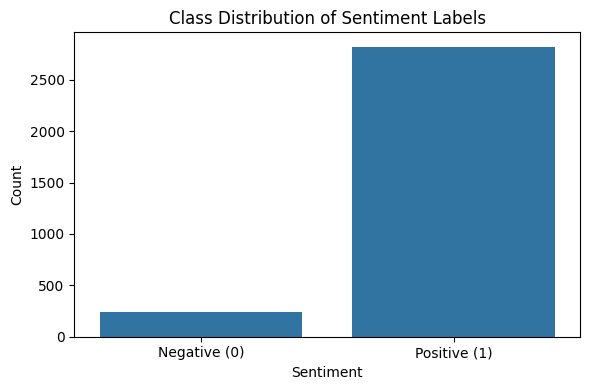

In [51]:
class_counts = df['feedback'].value_counts()
print(class_counts)
print("\nClass proportions:")
print(df['feedback'].value_counts(normalize=True).round(3))

fig, ax= plt.subplots(figsize=(6,4))
sns.countplot(x='feedback', data=df,  ax=ax)
ax.set_xticklabels(['Negative (0)', 'Positive (1)'])
ax.set_title('Class Distribution of Sentiment Labels')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


**Observation:** The dataset is highly imbalanced — the large majority of reviews are positive. "
We'll keep this in mind when training models (e.g. using `class_weight='balanced'`) and when choosing evaluation metrics (accuracy alone can be misleading, so we'll also look at precision/recall/F1).

## 2. Text Cleaning

In [39]:
custom_stopwords = set(sk_text.ENGLISH_STOP_WORDS)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)          # URLs
    text = re.sub(r'<.*?>', ' ', text)                    # HTML tags
    text = re.sub(r'&\w+;', ' ', text)                    # HTML entities like &#34;
    text = re.sub(r'[^a-z\s]', ' ', text)                 # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()              # extra whitespace
    tokens = [w for w in text.split() if w not in custom_stopwords and len(w) > 2]
    return ' '.join(tokens)

df['clean_text'] = df['verified_reviews'].apply(clean_text)
df[['verified_reviews', 'clean_text']].head(10)


,verified_reviews,clean_text
0,Love my Echo!,love echo
1,Loved it!,loved
2,"Sometimes while playing a game, you can answer...",playing game answer question correctly alexa s...
3,I have had a lot of fun with this thing. My 4 ...,lot fun thing old learns dinosaurs control lig...
4,Music,music
5,I received the echo as a gift. I needed anothe...,received echo gift needed bluetooth play music...
6,"Without having a cellphone, I cannot use many ...",having cellphone use features ipad use great a...
7,I think this is the 5th one I've purchased. I'...,think purchased working getting room house rea...
8,looks great,looks great
9,Love it! I’ve listened to songs I haven’t hear...,love listened songs haven heard childhood news...


In [40]:
# Drop rows that became empty after cleaning
df = df[df['clean_text'].str.len() > 0].reset_index(drop=True)
print("Rows after cleaning:", df.shape[0])


Rows after cleaning: 3058


## 3. Word Clouds — Positive vs Negative Reviews

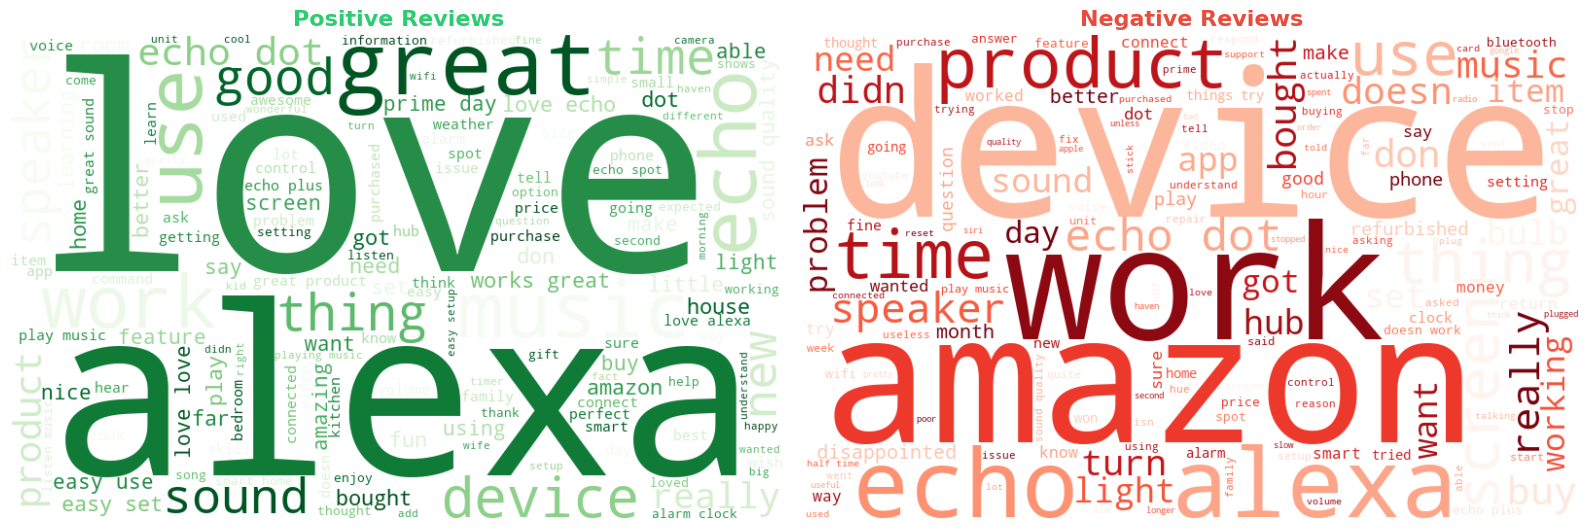

In [41]:
positive_text = ' '.join(df[df['feedback'] == 1]['clean_text'])
negative_text = ' '.join(df[df['feedback'] == 0]['clean_text'])

wc_pos = WordCloud(width=800, height=500, background_color='white',
                    colormap='Greens', max_words=150).generate(positive_text)
wc_neg = WordCloud(width=800, height=500, background_color='white',
                    colormap='Reds', max_words=150).generate(negative_text)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('Positive Reviews', fontsize=16, fontweight='bold', color='#2ecc71')
axes[0].axis('off')

axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('Negative Reviews', fontsize=16, fontweight='bold', color='#e74c3c')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Save individual word cloud images too, for reuse in the Streamlit app
wc_pos.to_file('images/wordcloud_positive.png')
wc_neg.to_file('images/wordcloud_negative.png')


## 4. Text Vectorization

**Why TF-IDF?**

We use **TF-IDF (Term Frequency–Inverse Document Frequency)** vectorization to convert the cleaned
review text into numerical features. TF-IDF was chosen over a simple Bag-of-Words / raw count
vectorizer because it down-weights common words that appear across many reviews (which carry
little discriminating power) and up-weights words that are more distinctive to a particular
review. This tends to produce cleaner, more informative features for linear classifiers such as
Logistic Regression and Linear SVM, and is a standard, lightweight, fast-to-train choice for
review-length text (as opposed to word embeddings, which need far more data/compute to pay off
here). We limit the vocabulary to the top 5,000 features and use unigrams + bigrams to also
capture short phrases like "not good".

In [42]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
X = tfidf.fit_transform(df['clean_text'])
y = df['feedback']
print("Feature matrix shape:", X.shape)


Feature matrix shape: (3058, 5000)


## 5. Train / Test Split & Model Training

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (2446, 5000)  Test shape: (612, 5000)


In [44]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Linear SVM': LinearSVC(class_weight='balanced', random_state=42)
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"Trained: {name}")


Trained: Logistic Regression
Trained: Linear SVM


## 6. Model Evaluation

In [45]:
results = []
preds_dict = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    preds_dict[name] = y_pred
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1})
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive'], zero_division=0))

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
results_df



=== Logistic Regression ===
              precision    recall  f1-score   support

    Negative       0.52      0.81      0.63        47
    Positive       0.98      0.94      0.96       565

    accuracy                           0.93       612
   macro avg       0.75      0.87      0.80       612
weighted avg       0.95      0.93      0.94       612


=== Linear SVM ===
              precision    recall  f1-score   support

    Negative       0.61      0.66      0.63        47
    Positive       0.97      0.96      0.97       565

    accuracy                           0.94       612
   macro avg       0.79      0.81      0.80       612
weighted avg       0.94      0.94      0.94       612



,Model,Accuracy,Precision,Recall,F1-Score
0,Linear SVM,0.941176,0.971480,0.964602,0.968028
1,Logistic Regression,0.928105,0.983302,0.938053,0.960145


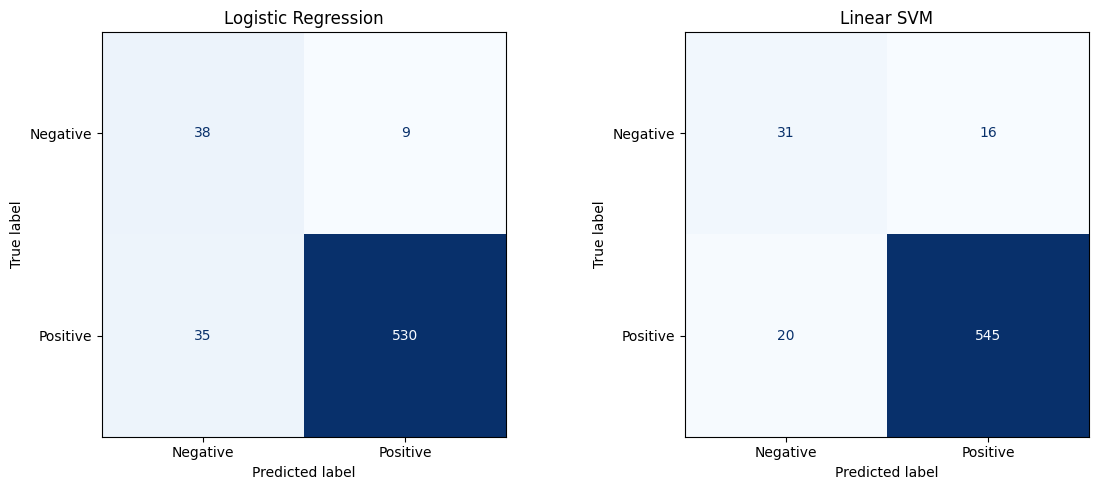

In [46]:
fig, axes = plt.subplots(1, len(trained_models), figsize=(6*len(trained_models), 5))
for ax, (name, y_pred) in zip(axes, preds_dict.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()


## 7. Compare Model Performance & Save the Best Model

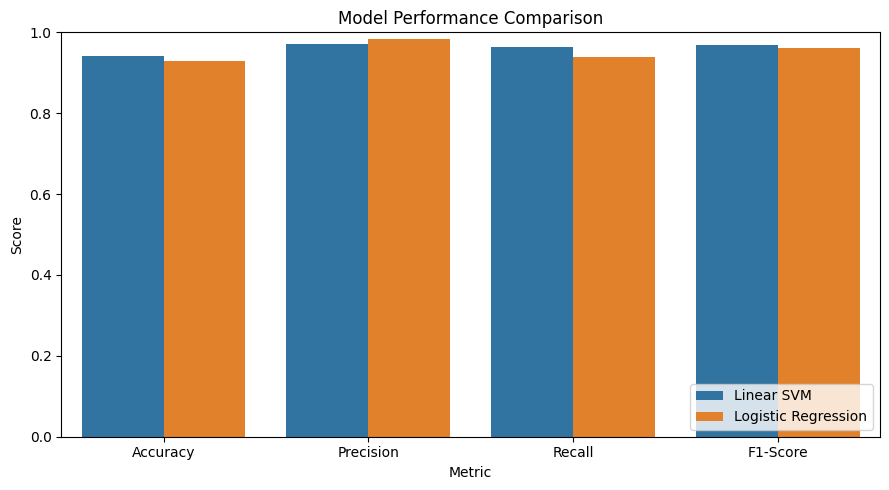

In [47]:
metrics_melt = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=metrics_melt, x='Metric', y='Score', hue='Model', ax=ax)
ax.set_title('Model Performance Comparison')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


In [48]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
print(f"Best performing model (by F1-Score): {best_model_name}")
results_df


Best performing model (by F1-Score): Linear SVM


,Model,Accuracy,Precision,Recall,F1-Score
0,Linear SVM,0.941176,0.971480,0.964602,0.968028
1,Logistic Regression,0.928105,0.983302,0.938053,0.960145


In [49]:
import os
os.makedirs('models', exist_ok=True)

joblib.dump(best_model, 'models/best_model.pkl')
joblib.dump(tfidf, 'models/tfidf_vectorizer.pkl')

with open('models/best_model_name.txt', 'w') as f:
    f.write(best_model_name)

print("Saved:")
print(" - models/best_model.pkl")
print(" - models/tfidf_vectorizer.pkl")
print(" - models/best_model_name.txt")


Saved:
 - models/best_model.pkl
 - models/tfidf_vectorizer.pkl
 - models/best_model_name.txt


## Summary

- Loaded and cleaned ~3,150 Amazon Alexa product reviews.
- Confirmed a strong class imbalance toward positive reviews.
- Cleaned text by lowercasing, removing HTML/URLs/punctuation/stopwords.
- Generated word clouds highlighting the most frequent terms in positive vs negative reviews.
- Vectorized text with TF-IDF (unigrams + bigrams, 5000 features).
- Trained and compared Logistic Regression and Linear SVM.
- Saved the best model and the TF-IDF vectorizer to `models/` for use in the Part 2 Streamlit dashboard.
